# HW02 Part 3: Analyze Hourly Wikipedia Events from S3

This notebook loads the hourly Parquet files directly from the private S3 bucket, combines them into one DataFrame, and visualizes hourly event counts.

In [1]:
# import 

from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
# test 

bucket_name = "dsan6000-sj1073"
s3_prefix = "wikipedia-hourly"

test_uri = (
    f"s3://{bucket_name}/{s3_prefix}/"
    "20260901_040000.parquet"
)

test_df = pd.read_parquet(test_uri)

print(f"Rows: {len(test_df):,}")
print("Columns:")
print(test_df.columns.tolist())

test_df.head()

Rows: 4,458
Columns:
['datetime', '$schema', 'meta', 'id', 'type', 'namespace', 'title', 'title_url', 'comment', 'timestamp', 'user', 'bot', 'notify_url', 'minor', 'length', 'revision', 'server_url', 'server_name', 'server_script_path', 'wiki', 'parsedcomment', 'log_id', 'log_type', 'log_action', 'log_params', 'log_action_comment', 'patrolled', 'file_ts', 'file_ts_str']


,datetime,$schema,meta,id,type,namespace,title,title_url,comment,timestamp,...,wiki,parsedcomment,log_id,log_type,log_action,log_params,log_action_comment,patrolled,file_ts,file_ts_str
0,2026-09-01 04:00:02,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/Jake_O%...,2.063884e+09,edit,0,Jake O'Donnell,https://en.wikipedia.org/wiki/Jake_O%27Donnell,Fix dash,1788235202,...,enwiki,Fix dash,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
1,2026-09-01 04:00:02,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/Beverid...,2.063884e+09,edit,0,Beveridge Award,https://en.wikipedia.org/wiki/Beveridge_Award,Add source,1788235202,...,enwiki,Add source,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
2,2026-09-01 04:00:01,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/1920_Un...,2.063884e+09,edit,0,1920 United States presidential election in Wa...,https://en.wikipedia.org/wiki/1920_United_Stat...,/* Counties that flipped from Democratic to Re...,1788235201,...,enwiki,"<span class=""autocomment""><a href=""/wiki/1920_...",NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
3,2026-09-01 04:00:02,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/1987_Ae...,2.063884e+09,edit,0,1987 Aegean crisis,https://en.wikipedia.org/wiki/1987_Aegean_crisis,added a bit of context,1788235202,...,enwiki,added a bit of context,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
4,2026-09-01 04:00:03,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/Marvin_...,2.063884e+09,edit,0,Marvin Schwäbe,https://en.wikipedia.org/wiki/Marvin_Schw%C3%A4be,NaN,1788235203,...,enwiki,NaN,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000


In [3]:
# load all Parquet files from the S3 bucket to the local data directory

import boto3

s3 = boto3.client("s3")

response = s3.list_objects_v2(
    Bucket=bucket_name,
    Prefix=f"{s3_prefix}/",
)

s3_uris = sorted(
    f"s3://{bucket_name}/{obj['Key']}"
    for obj in response.get("Contents", [])
    if obj["Key"].endswith(".parquet")
)

if len(s3_uris) != 24:
    raise ValueError(
        f"Expected 24 S3 Parquet files, but found {len(s3_uris)}."
    )

hourly_frames = []

for uri in s3_uris:
    hourly_frames.append(pd.read_parquet(uri))

events_df = pd.concat(hourly_frames, ignore_index=True)

print(f"Files loaded directly from S3: {len(s3_uris)}")
print(f"Combined DataFrame shape: {events_df.shape}")


Files loaded directly from S3: 24
Combined DataFrame shape: (119708, 29)


In [4]:
# aggregating the data to get hourly counts of events

events_df["datetime"] = pd.to_datetime(events_df["datetime"])
events_df["hour"] = events_df["datetime"].dt.floor("h")

hourly_counts = (
    events_df.groupby("hour")
    .size()
    .reset_index(name="event_count")
)

hourly_type_counts = (
    events_df.groupby(["hour", "type"])
    .size()
    .reset_index(name="event_count")
)

images_dir = Path("images")
images_dir.mkdir(exist_ok=True)

print(f"Hours represented: {hourly_counts['hour'].nunique()}")
print(f"Total events: {len(events_df):,}")
print("Event types:")
print(sorted(events_df["type"].dropna().unique()))

Hours represented: 24
Total events: 119,708
Event types:
['edit', 'log', 'new']


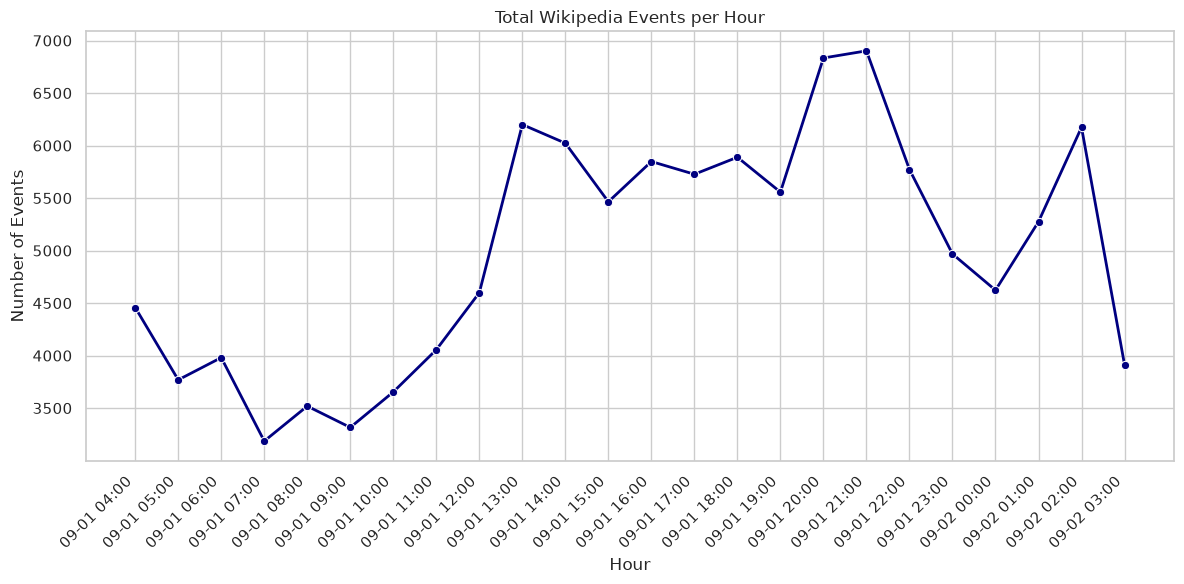

In [5]:
# total hourly events

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(12, 6))

sns.lineplot(
    data=hourly_counts,
    x="hour",
    y="event_count",
    marker="o",
    linewidth=2,
    color="navy",
    ax=ax,
)

ax.set_title("Total Wikipedia Events per Hour")
ax.set_xlabel("Hour")
ax.set_ylabel("Number of Events")
ax.set_xticks(hourly_counts["hour"])
ax.set_xticklabels(
    hourly_counts["hour"].dt.strftime("%m-%d %H:%M"),
    rotation=45,
    ha="right",
)

fig.tight_layout()
fig.savefig(images_dir / "hourly-events.png", dpi=300)
fig.savefig(images_dir / "hourly-events.svg")
plt.show()

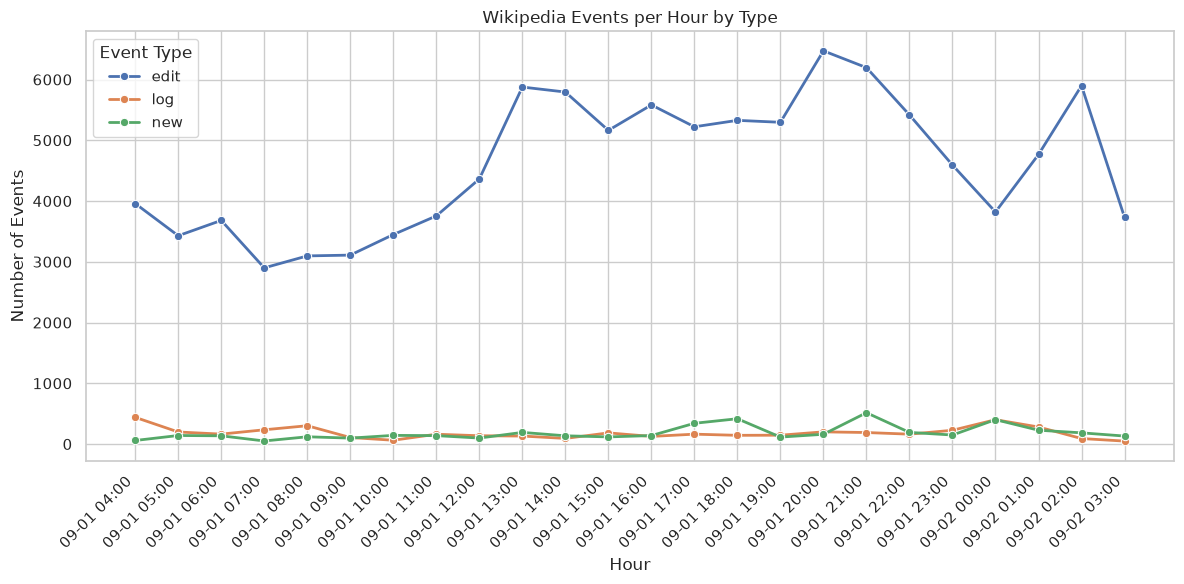

In [6]:
# hourly events by type

fig, ax = plt.subplots(figsize=(12, 6))

sns.lineplot(
    data=hourly_type_counts,
    x="hour",
    y="event_count",
    hue="type",
    marker="o",
    linewidth=2,
    ax=ax,
)

ax.set_title("Wikipedia Events per Hour by Type")
ax.set_xlabel("Hour")
ax.set_ylabel("Number of Events")
ax.set_xticks(hourly_counts["hour"])
ax.set_xticklabels(
    hourly_counts["hour"].dt.strftime("%m-%d %H:%M"),
    rotation=45,
    ha="right",
)
ax.legend(title="Event Type")

fig.tight_layout()
fig.savefig(images_dir / "events-by-type.png", dpi=300)
fig.savefig(images_dir / "events-by-type.svg")
plt.show()